In [ ]:
# 구글 마운트 하세요

In [1]:
# 운영 체제와 상호 작용하는 함수(예: 파일 처리)를 불러옴.
import os

# 시간 관련 함수(예: 시간 측정)를 불러옴.
import time

# 객체를 깊은 복사(deep copy)하기 위한 모듈을 불러옴.
import copy

# NumPy 라이브러리를 np 별칭으로 불러옴. 배열 및 수치 연산에 사용함.
import numpy as np

# Matplotlib의 pyplot 모듈을 plt 별칭으로 불러옴. 데이터 시각화에 사용함.
import matplotlib.pyplot as plt

# PyTorch 핵심 라이브러리를 불러옴.
import torch

# TorchVision 라이브러리를 불러옴.
import torchvision

# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn

# 옵티마이저(optim) 모듈을 불러옴.
import torch.optim as optim

# 학습률 스케줄러(lr_scheduler) 모듈을 불러옴. 학습률 조정에 사용함.
from torch.optim import lr_scheduler

# TorchVision에서 데이터셋, 미리 학습된 모델, 데이터 변환 모듈을 불러옴.
from torchvision import datasets, models, transforms

# PyTorch의 난수 생성기 시드(seed) 값을 0으로 설정했음. 재현성을 보장함.
torch.manual_seed(0)

In [2]:
# PyTorch의 핵심 라이브러리를 불러옴.
import torch
# PyTorch의 자동 미분 기능(Autograd)을 위한 Variable 클래스를 불러옴. (최신 PyTorch에서는 텐서가 대체함)
from torch.autograd import Variable
# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn
# 함수형 신경망 연산(F) 모듈을 불러옴.
import torch.nn.functional as F
# 옵티마이저(optim) 모듈을 불러옴.
from torch import optim

# TorchVision 라이브러리를 불러옴.
import torchvision
# 이미지 변환(transforms) 모듈을 불러옴.
from torchvision import transforms

# PIL 라이브러리의 Image 모듈을 불러옴. 이미지 처리에 사용함.
from PIL import Image
# 순서가 보장되는 딕셔너리(OrderedDict) 클래스를 불러옴. (특정 구조 저장에 유용함)
from collections import OrderedDict

In [3]:
# GRAM MATRIX 계산
class GramMatrix(nn.Module):
    def forward(self, input):
        # 입력 텐서 batch, channel, height, width 추출(4D 이미지, NCHW)
        b, c, h, w = input.size()

        # 텐서를 (batch, channel, height*width) 형태로 flatten(평탄화)함
        # 이 구현에서 batch 차원은 유지하고 channel 차원만 평탄화해야 함 (b, c, h*w)
        # M = H * W
        F = input.view(b, c, h*w)

        # 배치 행렬 곱셈(bmm) 사용, gram matrix (G) 계산
        # F(feature map: 특징맵)와 F의 채널-공간 차원 전치(transpose)를 곱함 결과크기 (b, c, c)
        # 원래 F.shape = (b,c,h*w) h*w를 n이라고 하면 (b,c,n)
        # batch는 남겨두고 F.transpose(1,2)하면 (b,n,c)
        # 두 feature map 간의 내적하면 (b,c,c)
        # 이게 무엇을 의미하는가? batch_size 는 남겨두고 [c,c 채널 간 상관관계] 파악
        # i번째 채널과 j번째 채널이 얼마나 이미지에 동시에 활성화되었는 가 파악
        # 예를 들어 1번채널이 선 64번 채널이 색상 >> 선과 색상이 같이 활성화 되는가?
        # 여기서 잠깐 잊지말자. w*h=n이 였는데 없어졌네 (위치 정보 제거됨)
        # 위치 필요없어. 오직 스타일뿐 (질감, 색상)
        # "BCC" 나에게 필요한 건 오직 스타일 뿐 (스타일 트랜스퍼)
        G = torch.bmm(F, F.transpose(1,2))

        # Gram matrix을 height * width 나누어요 >> 정규화
        # 이미지 해상도에 따른 편차 제거 위함 (h*w = n 전체 픽셀 수)
        # >> 이미지 크기에 관계없이 일정한 값 가지도록 함 (단위 unit 당)
        G.div_(h*w)

        return G

# Gram Matrix 이용, MSE(평균 제곱 오차) 손실을 계산하는 모듈 정의
class GramMSELoss(nn.Module):
    def forward(self, input, target):
        # GramMatrix 모듈 통과 gram matrix 계산함
        # >> 목표(target) gram matrix MSE 손실 계산
        out = nn.MSELoss()(GramMatrix()(input), target)
        # 계산된 스타일 손실 (style loss) 반환
        return(out)


Content Loss(콘텐츠 손실)

In [4]:
class VGG(nn.Module):
    def __init__(self, pool='max'):
        super(VGG, self).__init__()
        #vgg modules
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        if pool == 'max':
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool == 'avg':
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x, out_keys):
        out = {}
        out['r11'] = F.relu(self.conv1_1(x))
        out['r12'] = F.relu(self.conv1_2(out['r11']))
        out['p1'] = self.pool1(out['r12'])
        out['r21'] = F.relu(self.conv2_1(out['p1']))
        out['r22'] = F.relu(self.conv2_2(out['r21']))
        out['p2'] = self.pool2(out['r22'])
        out['r31'] = F.relu(self.conv3_1(out['p2']))
        out['r32'] = F.relu(self.conv3_2(out['r31']))
        out['r33'] = F.relu(self.conv3_3(out['r32']))
        out['r34'] = F.relu(self.conv3_4(out['r33']))
        out['p3'] = self.pool3(out['r34'])
        out['r41'] = F.relu(self.conv4_1(out['p3']))
        out['r42'] = F.relu(self.conv4_2(out['r41']))
        out['r43'] = F.relu(self.conv4_3(out['r42']))
        out['r44'] = F.relu(self.conv4_4(out['r43']))
        out['p4'] = self.pool4(out['r44'])
        out['r51'] = F.relu(self.conv5_1(out['p4']))
        out['r52'] = F.relu(self.conv5_2(out['r51']))
        out['r53'] = F.relu(self.conv5_3(out['r52']))
        out['r54'] = F.relu(self.conv5_4(out['r53']))
        out['p5'] = self.pool5(out['r54'])
        return [out[key] for key in out_keys]

        # 특정 layer 이름 지정(r11, r42) >> 결과값만 쏙 골라오기 위해서

In [5]:
vgg = VGG()

# 로드할 이미지 파일 이름들을 정의함. ('vangogh_starry_night.jpg', 'Tuebingen_Neckarfront.jpg')
img1 = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/vangogh_starry_night.jpg'
img2 = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/Tuebingen_Neckarfront.jpg'

# 이미지 디렉토리와 파일 이름을 결합하여 PIL Image 객체 리스트로 로드함.
img1 = Image.open(img1)
img2 = Image.open(img2)
imgs = []
imgs.append(img1)
imgs.append(img2)

# img1
# img2

imgs

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=960x760>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=960x720>]

In [6]:
img_size = 512

prep =\
transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(), # [0-1] 범위
        transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]),
        # RGB >> BGR 변환 (VGG 가 BGR 변환)
        transforms.Normalize(mean = [0.40760392,0.45795686,0.48501961],
                             std=[1,1,1]),
        # std=[1,1,1] >> 1로 나누니깐 평균만 뺄거야.
        transforms.Lambda(lambda x: x.mul_(255))
        # 0과 1 인 값에 255 곱해서 0-255 범위로 변경(VGG가 0-255 이였기 때문에)
    ]
)

# 각 PIL Image 객체에 사전 정의된 전처리 함수(prep) 적용 >> 텐서로 변환
imgs_torch = [prep(img) for img in imgs]

# print(imgs_torch)

# if torch.cuda.is_available():
#     imgs_torch  = [Variable(img.unsqueeze(0).cuda()) for img in imgs_torch]
#     # 배치차원만 추가 >> Variable(자동미분 기능 포함) 저장
# else:
#     imgs_torch = [Variable(img.unsqueeze(0)) for img in imgs_torch]

# 누가 요즘 Variable() 써요. 텐서면 자동미분 되요.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

imgs_torch = [img.unsqueeze(0).to(device) for img in imgs_torch]

# 이미지 텐서 리스트를 스타일 이미지와 콘텐츠 이미지 변수에 할당
style_image, content_image = imgs_torch

print(style_image.shape)
# torch.Size([1, 3, 512, 512])
print(content_image.shape)
# torch.Size([1, 3, 512, 512])

# opt_img = Variable(content_image.data.clone(), requires_grad=True)
# 콘텐츠 이미지의 데이터 복사본으로 최적화하기 위해 초기화함
# requires_grad=True 이 이미지 픽셀을 최적화하여 학습하도록 하겠다

opt_img = content_image.detach().clone().requires_grad_(True)
# detach() 자동미분 계산하면서 이전 계산 기록을 끊어내기 위해
# requires_grad_(True) 모델의 가중치 변경하는 게 아님 이미지가 가진 pixel 학습대상
# 여기서는 noise 대신 콘텐츠 이미지를 줘서 그 위에 스타일 입히게 함


# 정답지 역할 수행(기준점)
# 절대로 변하면 안되는 고정된 값
# content image의 형태, 위치 기준 정답지
# style image의 화풍(스타일, 질감, 색상) 기준 정답지

# opt_img (새로운 이미지) >> input image로 들어감
# content image 와 opt_img 를 vgg(cnn 모델)에 넣었을 때 나오는 결과값과 비교
# style image와 opt_img 를 vgg(cnn 모델)에 넣었을 때 나오는 결과값과 비교

torch.Size([1, 3, 512, 512])
torch.Size([1, 3, 512, 512])


In [7]:
from torch.cuda import is_available
import torch
import torch.nn as nn

vgg = vgg.to(device)

# 스타일 손실 계산할 VGG layer 이름 정의
# r11, r21 >> vgg 내부의 특정 합성곱 레이어 나타냄(relu 통과한 층)
# 낮은 레이어 (이미지의 아주 세밀한 형태 경계선, 점, 색상)
style_layers = ['r11', 'r21', 'r31', 'r41', 'r51']

# 콘텐츠 손실 계산할 VGG layer 이름 정의
# 일반적으로 중간 레이어 하나 사용
# 왜? 객체의 눈. 코. 압 전체적인 윤곽
content_layers = ['r42']

loss_layers = style_layers + content_layers
# 사용할 모든 손실 레이어 = 스타일 손실 + 콘텐츠 손실

# 각 스타일에 대해 GramMSELoss  모듈 적용
# 콘텐츠에 대해서는 MSELoss 모듈 사용

loss_fn = [GramMSELoss()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)

if torch.cuda.is_available():
    # loss_fns 리스트의 요소들을 새로운 모듈 인스턴스로 만들고 .cuda() 적용
    # 리스트 복사를 방지하고 정확하게 gpu로 이동하기 위해 수정
    # '_' 의미는? 단지 리스트의 개수만큼 반복
    loss_fns = [GramMSELoss().to(device) for _ in style_layers] +\
               [nn.MSELoss().to(device) for _ in content_layers]
else:
    loss_fns = [GramMSELoss().to(device) for _ in style_layers] +\
               [nn.MSELoss().to(device) for _ in content_layers]

# 스타일 손실에 부여할 가중치(weithgs) 정의함.
# 깊은 레이어일 수록 낮은 가중치를 주는 경향이 있음
# >> 최종적으로 스타일 손실은 (b, c, c) c*c
# >> 채널수가 적은 쪽에 높은 가중치, 채널수가 많은 뒤쪽에는 작은 가중치를 부여해야
# >> 전체적인 손실 규모를 맞춰주게 됨 >> 일종의 정규화 효과
# n : 채널(필터) 수

style_weights = [1e3/n**2 for n in [64, 128, 256, 512, 512]]

# 콘텐츠 손실에 부여할 가중치(weights) 정의
content_weights = [1e0]

# 최종적으로 사용할 모든 가중치 리스트
weights = style_weights + content_weights

# 최적화 목표값(style targets) 계산
# style_image를 vgg에 통과 시켜 각 style_layers 의 Gram Matrix 계산
style_targets =\
[GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]

# 최적화 목표값(content targets) 계산
content_targets =\
[A.detach() for A in vgg(content_image, content_layers)]

# 최종적으로 사용할 모든 목표값 리스트 정의
targets = style_targets + content_targets

targets

[tensor([[[ 26.8737,  16.3401,   4.1984,  ...,   3.2507,   7.3200,  14.4376],
          [ 16.3401, 168.5590,  32.6240,  ...,  11.6474,  29.2171,  32.5917],
          [  4.1984,  32.6240,  66.8521,  ...,  17.2325,  11.5290,  34.4180],
          ...,
          [  3.2507,  11.6474,  17.2325,  ...,  10.9148,   5.5984,  14.7139],
          [  7.3200,  29.2171,  11.5290,  ...,   5.5984,  12.3937,  15.1786],
          [ 14.4376,  32.5917,  34.4180,  ...,  14.7139,  15.1786,  55.2938]]],
        device='cuda:0'),
 tensor([[[1.9937e+01, 1.1836e+01, 9.3144e+00,  ..., 7.7321e+00,
           5.9136e-03, 3.5052e+00],
          [1.1836e+01, 1.7835e+01, 9.8227e+00,  ..., 1.0099e+01,
           1.2380e-02, 1.6270e+00],
          [9.3144e+00, 9.8227e+00, 1.3505e+01,  ..., 8.8594e+00,
           8.2340e-03, 1.5623e+00],
          ...,
          [7.7321e+00, 1.0099e+01, 8.8594e+00,  ..., 1.1117e+01,
           1.3418e-02, 9.3521e-01],
          [5.9136e-03, 1.2380e-02, 8.2340e-03,  ..., 1.3418e-02,
     

In [8]:
input_image = content_image.clone().requires_grad_(True)
# input_image 는 vgg 에 입력될 초기 이미지. 콘텐츠 이미지와 동일한 형태여야만 함

In [14]:
optimizer = torch.optim.LBFGS([input_image], max_iter=1)

# LBFGS 특징 : 2차미분(헤시안 Hessian) 근사치 사용 (극소값, 극대값, 안장값 판별)
# 왜 Adam보다 선호되는가? 헤시안 사용하여 근사치를 구한 결과가 더 정교하고 빠르게 최적의 픽셀 값을 찾아내는 데 도움
# 우리는 단 1장의 이미지(input_image)만 최적화하면 됨
# LBFGS는 적은 데이터에 더 선명하고 고품질의 결과물을 가져오는 경향이 있음
# LBFGS 사용하면 closure() 사용해야 함 (최대 단점: 현재 상태에 여러번 기울기를 반복 계산)
# https://angeloyeo.github.io/2020/06/17/Hessian.html

# 헤시안이 알려주는 지형 정보
# 양수 (+6, +4) 아래로 볼록 (골짜기) 주변 대비 가장 낮은 최소값
# 음수 (-3, -2) 위로 볼록 (봉우리) 주변 대비 가장 높은 최대값
# 양수와 음수 혼합 말 안장 모양(한쪽은 올라가고 한쪽은 내려간 안장점(saddle point))

In [10]:
# 최적화 횟수를 세기 위한 변수
n_iter = 0

In [11]:
def closure():
    global n_iter

    optimizer.zero_grad()

    # 생성된 이미지(input_image) 를 vgg 통과 >> 특징맵 추출
    out = vgg(input_image, loss_layers)

    # 총손실 계산
    layer_losses = []
    total_loss = 0

    for i, weight in enumerate(weights):
         target = targets[i]
         feature = out[i]
         loss_fn = loss_fns[i]

         loss= weight * loss_fn(feature, target)
         layer_losses.append(loss.item())
         total_loss += loss

    # 역전파 수행
    total_loss.backward()

    # 진행상황 출력
    if n_iter % 50 == 0:
        print(f'Iteration {n_iter}: Total Loss={total_loss.item():.4f}')

    n_iter += 1
    return total_loss


# 최적화 실행(반복 횟수 지정)
num_iterations = 500

for i in range(num_iterations):
    optimizer.step(closure)
    # LBFGS 는 step() 호출 할 때마다 closure() 여러 번 호출 가능

# 최종 결과 이미지 후처리
# 생성된 이미지를 [0,1] 범위로 클리핑하여 픽셀값 보정
input_image.data.clamp_(0,1)


Iteration 0: Total Loss=6533.6128
Iteration 50: Total Loss=0.0397
Iteration 100: Total Loss=0.0028
Iteration 150: Total Loss=0.0028
Iteration 200: Total Loss=0.0028
Iteration 250: Total Loss=0.0028
Iteration 300: Total Loss=0.0028
Iteration 350: Total Loss=0.0028
Iteration 400: Total Loss=0.0028
Iteration 450: Total Loss=0.0028


tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 1., 1., 1.],
          [0., 0., 0.,  ..., 1., 1., 1.],
          [0., 0., 0.,  ..., 1., 1., 1.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 1., 1., 1.],
          [0., 0., 0.,  ..., 1., 1., 1.],
          [0., 0., 0.,  ..., 1., 1., 1.]]]], device='cuda:0')

In [12]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np

def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0) # 배치차원 제거 (1,C, H, W) >> (C,H,W)
    unloader = transforms.ToPILImage()  # PIL 이미지로 변경
    image = unloader(image)

    if title is not None:
        plt.title(title)

    plt.imshow(image)
    plt.pause(0.001)      # 잠시 멈춰서 그림 보여줘

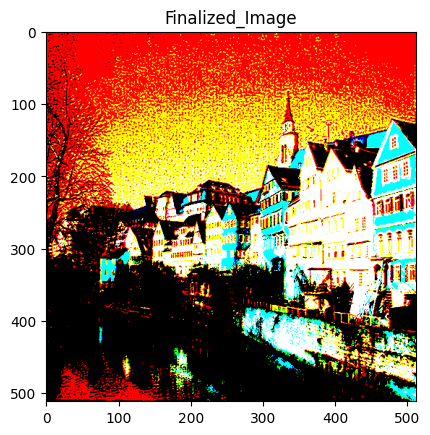

In [13]:
imshow(input_image.data, title='Finalized_Image')
plt.show()

In [ ]:
# eos